In [14]:
import pandas as pd
import  numpy as np
from io import  StringIO
csv_data='''
A,B,C,D,E
2,3,4,5,
6,34,6,
10,,11,8,
,,,
3,,3,,
,5,,,
'''
fill = pd.read_csv(StringIO(csv_data))
print(fill)
fillmean1 =  fill.mean()
print(fillmean1)
for x in fill:
    fill[x] = fill[x].fillna(fillmean1.loc[x])
    
print(fill)    

      A     B     C    D   E
0   2.0   3.0   4.0  5.0 NaN
1   6.0  34.0   6.0  NaN NaN
2  10.0   NaN  11.0  8.0 NaN
3   NaN   NaN   NaN  NaN NaN
4   3.0   NaN   3.0  NaN NaN
5   NaN   5.0   NaN  NaN NaN
A     5.25
B    14.00
C     6.00
D     6.50
E      NaN
dtype: float64
       A     B     C    D   E
0   2.00   3.0   4.0  5.0 NaN
1   6.00  34.0   6.0  6.5 NaN
2  10.00  14.0  11.0  8.0 NaN
3   5.25  14.0   6.0  6.5 NaN
4   3.00  14.0   3.0  6.5 NaN
5   5.25   5.0   6.0  6.5 NaN


### 檢查重複

In [17]:
import pandas as pd
import  numpy as np
from io import  StringIO
csv_data='''
A,B,C,D
2,3,5,5
5,5,5,5
5,5,5,5
13,23,5,5
'''
df2=pd.read_csv(StringIO(csv_data))
print(df2)
print(df2.duplicated())
print(df2.duplicated("A"))

    A   B  C  D
0   2   3  5  5
1   5   5  5  5
2   5   5  5  5
3  13  23  5  5
0    False
1    False
2     True
3    False
dtype: bool
0    False
1    False
2     True
3    False
dtype: bool


### 丟棄重複值的資料

In [27]:
import pandas as pd
import  numpy as np
from io import  StringIO
csv_data='''
A,B,C,D
2,3,5,5
5,5,5,5
5,5,5,5
13,23,5,5
'''
df2=pd.read_csv(StringIO(csv_data))
print(df2)
print(df2.drop_duplicates())
print("="*30)
print(df2.drop_duplicates(keep="last"))
print("="*30)
print(df2.drop_duplicates(keep=False))
print("="*30)
print(df2.drop_duplicates(subset=["C","D"],keep="last"))
print("="*30)
print(df2.drop_duplicates(subset=["C","D"],keep=False))
print("="*30)
print(df2.drop_duplicates(subset=["A","D"],keep=False))
print("="*30)

    A   B  C  D
0   2   3  5  5
1   5   5  5  5
2   5   5  5  5
3  13  23  5  5
    A   B  C  D
0   2   3  5  5
1   5   5  5  5
3  13  23  5  5
    A   B  C  D
0   2   3  5  5
2   5   5  5  5
3  13  23  5  5
    A   B  C  D
0   2   3  5  5
3  13  23  5  5
    A   B  C  D
3  13  23  5  5
Empty DataFrame
Columns: [A, B, C, D]
Index: []
    A   B  C  D
0   2   3  5  5
3  13  23  5  5


## Pand群組

In [29]:
import pandas as pd
import numpy as np
company=["A","B","C"]
data1=pd.DataFrame(
{"company":[company[x] for x in np.random.randint(0,len(company),20)],
"salary":np.random.randint(5,50,20),
"age":np.random.randint(15,50,20)}    
)
print(data1)

   company  salary  age
0        C      19   22
1        C       8   45
2        B      20   31
3        A      33   23
4        A      28   25
5        C      13   22
6        A      33   20
7        B      25   15
8        A       8   21
9        C      24   21
10       A      15   18
11       A      37   38
12       A      36   34
13       A      33   35
14       C      24   43
15       A      20   24
16       A      33   20
17       A      19   49
18       A      17   46
19       C      36   17


In [30]:
group = data1.groupby("company")
print(list(group))

[('A',    company  salary  age
3        A      33   23
4        A      28   25
6        A      33   20
8        A       8   21
10       A      15   18
11       A      37   38
12       A      36   34
13       A      33   35
15       A      20   24
16       A      33   20
17       A      19   49
18       A      17   46), ('B',   company  salary  age
2       B      20   31
7       B      25   15), ('C',    company  salary  age
0        C      19   22
1        C       8   45
5        C      13   22
9        C      24   21
14       C      24   43
19       C      36   17)]


In [31]:
print(group.size())
print(group.first())
print(group.last())


company
A    12
B     2
C     6
dtype: int64
         salary  age
company             
A            33   23
B            20   31
C            19   22
         salary  age
company             
A            17   46
B            25   15
C            36   17


In [32]:
import os
print(os.getcwd())

C:\Users\xvpow\ai_20260426\ch11


In [36]:
import pandas as pd
fortune = pd.read_csv("fortune1000.csv",index_col = "Rank")
print(fortune.head(3))

          Company      Sector                     Industry         Location  \
Rank                                                                          
1         Walmart   Retailing        General Merchandisers  Bentonville, AR   
2     Exxon Mobil      Energy           Petroleum Refining       Irving, TX   
3           Apple  Technology  Computers, Office Equipment    Cupertino, CA   

      Revenue  Profits  Employees  
Rank                               
1      482130    14694    2300000  
2      246204    16150      75600  
3      233715    53394     110000  


In [37]:
sectors = fortune.groupby("Sector")
print(sectors.size())

Sector
Aerospace & Defense              20
Apparel                          15
Business Services                51
Chemicals                        30
Energy                          122
Engineering & Construction       26
Financials                      139
Food and Drug Stores             15
Food, Beverages & Tobacco        43
Health Care                      75
Hotels, Resturants & Leisure     25
Household Products               28
Industrials                      46
Materials                        43
Media                            25
Motor Vehicles & Parts           24
Retailing                        80
Technology                      102
Telecommunications               15
Transportation                   36
Wholesalers                      40
dtype: int64


In [39]:
print(sectors.get_group("Energy").head(5))

                 Company  Sector            Industry         Location  \
Rank                                                                    
2            Exxon Mobil  Energy  Petroleum Refining       Irving, TX   
14               Chevron  Energy  Petroleum Refining    San Ramon, CA   
30           Phillips 66  Energy  Petroleum Refining      Houston, TX   
32         Valero Energy  Energy  Petroleum Refining  San Antonio, TX   
42    Marathon Petroleum  Energy  Petroleum Refining      Findlay, OH   

      Revenue  Profits  Employees  
Rank                               
2      246204    16150      75600  
14     131118     4587      61500  
30      87169     4227      14000  
32      81824     3990      10103  
42      64566     2852      45440  


In [42]:
sectors.sum(numeric_only=True)

,Revenue,Profits,Employees
Sector,,,
Aerospace & Defense,357940,28742,968057
Apparel,95968,8236,346397
Business Services,272195,28227,1361050
Chemicals,243897,22628,463651
Energy,1517809,-73447,1188927
Engineering & Construction,153983,5304,406708
Financials,2217159,260209,3359948
Food and Drug Stores,483769,16759,1395398
"Food, Beverages & Tobacco",555967,51417,1211632


In [43]:
sectors.mean(numeric_only = True)

,Revenue,Profits,Employees
Sector,,,
Aerospace & Defense,17897.000000,1437.100000,48402.850000
Apparel,6397.866667,549.066667,23093.133333
Business Services,5337.156863,553.470588,26687.254902
Chemicals,8129.900000,754.266667,15455.033333
Energy,12441.057377,-602.024590,9745.303279
Engineering & Construction,5922.423077,204.000000,15642.615385
Financials,15950.784173,1872.007194,24172.287770
Food and Drug Stores,32251.266667,1117.266667,93026.533333
"Food, Beverages & Tobacco",12929.465116,1195.744186,28177.488372


In [48]:
df_numeric = fortune.select_dtypes(include="number")
df_numeric


,Revenue,Profits,Employees
Rank,,,
1,482130,14694,2300000
2,246204,16150,75600
3,233715,53394,110000
4,210821,24083,331000
5,181241,1476,70400
...,...,...,...
996,1902,-47,3448
997,1898,172,2646
997,1898,172,2646


In [46]:
fortune.select_dtypes(exclude="number")

,Company,Sector,Industry,Location
Rank,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR"
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX"
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA"
4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),"Omaha, NE"
5,McKesson,Health Care,Wholesalers: Health Care,"San Francisco, CA"
...,...,...,...,...
996,New York Community Bancorp,Financials,Commercial Banks,"Westbury, NY"
997,Portland General Electric,Energy,Utilities: Gas and Electric,"Portland, OR"
997,Portland General Electric,Energy,Utilities: Gas and Electric,"Portland, OR"


In [54]:
sectors.agg("sum",numeric_only=True)

,Revenue,Profits,Employees
Sector,,,
Aerospace & Defense,357940,28742,968057
Apparel,95968,8236,346397
Business Services,272195,28227,1361050
Chemicals,243897,22628,463651
Energy,1517809,-73447,1188927
Engineering & Construction,153983,5304,406708
Financials,2217159,260209,3359948
Food and Drug Stores,483769,16759,1395398
"Food, Beverages & Tobacco",555967,51417,1211632


In [59]:
sectors.agg({"Revenue":["sum","mean","size"],"Employees":"mean"},numeric_only=True)

Revenue                        Employees
                                  sum          mean size          mean
Sector                                                                
Aerospace & Defense            357940  17897.000000   20  48402.850000
Apparel                         95968   6397.866667   15  23093.133333
Business Services              272195   5337.156863   51  26687.254902
Chemicals                      243897   8129.900000   30  15455.033333
Energy                        1517809  12441.057377  122   9745.303279
Engineering & Construction     153983   5922.423077   26  15642.615385
Financials                    2217159  15950.784173  139  24172.287770
Food and Drug Stores           483769  32251.266667   15  93026.533333
Food, Beverages & Tobacco      555967  12929.465116   43  28177.488372
Health Care                   1614707  21529.426667   75  35710.520000
Hotels, Resturants & Leisure   169546   6781.840000   25  99369.800000
Household Products             234737   8383.464286   28  23072.785714
Industrials                    497581  10816.978261   46  33591.934783
Materials                      259145   6026.627907   43  14840.069767
Media                          220764   8830.560000   25  22012.560000
Motor Vehicles & Parts         482540  20105.833333   24  45106.666667
Retailing                     1465076  18313.450000   80  77845.362500
Technology                    1377600  13505.882353  102  35087.735294
Telecommunications             461834  30788.933333   15  55497.866667
Transportation                 408508  11347.444444   36  42688.694444
Wholesalers                    444800  11120.000000   40  13139.925000

In [63]:
import pandas as pd
auto_price = pd.read_csv("Automobile.csv")
print(auto_price.head())
print(auto_price.columns)

   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compression-ratio hor

In [64]:
print(auto_price.isnull().any())

symboling            False
normalized-losses    False
make                 False
fuel-type            False
aspiration           False
num-of-doors         False
body-style           False
drive-wheels         False
engine-location      False
wheel-base           False
length               False
width                False
height               False
curb-weight          False
engine-type          False
num-of-cylinders     False
engine-size          False
fuel-system          False
bore                 False
stroke               False
compression-ratio    False
horsepower           False
peak-rpm             False
city-mpg             False
highway-mpg          False
price                False
dtype: bool


In [65]:
auto_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [69]:
import numpy as np
list1 =[]
for col in auto_price:
    for filed in auto_price[col]:
        if filed == "?":
            list1.append(col)
            break
print(list1)            

['normalized-losses', 'num-of-doors', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']


In [70]:
for column in list1:
    auto_price.loc[auto_price[column] == "?",column ] = np.nan
print(auto_price.isnull().any())    

symboling            False
normalized-losses     True
make                 False
fuel-type            False
aspiration           False
num-of-doors          True
body-style           False
drive-wheels         False
engine-location      False
wheel-base           False
length               False
width                False
height               False
curb-weight          False
engine-type          False
num-of-cylinders     False
engine-size          False
fuel-system          False
bore                  True
stroke                True
compression-ratio    False
horsepower            True
peak-rpm              True
city-mpg             False
highway-mpg          False
price                 True
dtype: bool


In [71]:
auto_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [73]:
auto_price.isna().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [77]:
try:
    auto_price.drop(["normalized-losses"],axis=1,inplace = True)
except:
    pass


In [78]:
auto_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   make               205 non-null    str    
 2   fuel-type          205 non-null    str    
 3   aspiration         205 non-null    str    
 4   num-of-doors       203 non-null    str    
 5   body-style         205 non-null    str    
 6   drive-wheels       205 non-null    str    
 7   engine-location    205 non-null    str    
 8   wheel-base         205 non-null    float64
 9   length             205 non-null    float64
 10  width              205 non-null    float64
 11  height             205 non-null    float64
 12  curb-weight        205 non-null    int64  
 13  engine-type        205 non-null    str    
 14  num-of-cylinders   205 non-null    str    
 15  engine-size        205 non-null    int64  
 16  fuel-system        205 non-null    st

In [79]:
auto_price.isnull().sum()

symboling            0
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64

In [80]:
auto_price.dropna(inplace=True)
auto_price.isnull().sum()

symboling            0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [95]:
from pandas.api.types import is_string_dtype
list3 = []
for i in auto_price:
    #print( auto_price[i].dtypes, is_string_dtype(auto_price[i]))
    if is_string_dtype(auto_price[i]):
        try:
           auto_price[i] = auto_price[i].astype("float")  
           list3.append(i) 
        except:
            pass
print(list3)            

['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']


In [96]:
auto_price.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,0.797927,98.923834,174.326425,65.893782,53.869948,2561.507772,128.124352,3.330622,3.248860,10.143627,103.481865,5099.740933,25.326425,30.787565,13285.025907
std,1.235582,6.152409,12.478593,2.137795,2.394770,526.700026,41.590452,0.272385,0.315421,3.977491,37.960107,468.694369,6.387828,6.816910,8089.082886
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,98.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,19.000000,25.000000,7738.000000
50%,1.000000,97.000000,173.200000,65.400000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5100.000000,25.000000,30.000000,10245.000000
75%,2.000000,102.400000,184.600000,66.900000,55.700000,2952.000000,146.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16515.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [98]:
auto_price.describe(include=["str"])

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
count,193,193,193,193,193,193,193,193,193,193
unique,21,2,2,2,5,3,2,5,6,7
top,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,32,174,158,112,92,114,190,141,153,88


In [101]:
cols4 = []#字串
cols5 = [] #數字
from pandas.api.types import is_string_dtype
for i in  auto_price:
    if is_string_dtype(auto_price[i]):
        cols4.append(i)
    else:
        cols5.append(i)

In [102]:
for colum in cols4:
    print("欄位名稱:",colum)
    print(auto_price[colum].value_counts())
    print()

欄位名稱: make
make
toyota           32
nissan           18
honda            13
mitsubishi       13
mazda            12
subaru           12
volkswagen       12
peugot           11
volvo            11
bmw               8
dodge             8
mercedes-benz     8
plymouth          7
audi              6
saab              6
porsche           4
alfa-romero       3
chevrolet         3
jaguar            3
isuzu             2
mercury           1
Name: count, dtype: int64

欄位名稱: fuel-type
fuel-type
gas       174
diesel     19
Name: count, dtype: int64

欄位名稱: aspiration
aspiration
std      158
turbo     35
Name: count, dtype: int64

欄位名稱: num-of-doors
num-of-doors
four    112
two      81
Name: count, dtype: int64

欄位名稱: body-style
body-style
sedan          92
hatchback      63
wagon          24
hardtop         8
convertible     6
Name: count, dtype: int64

欄位名稱: drive-wheels
drive-wheels
fwd    114
rwd     71
4wd      8
Name: count, dtype: int64

欄位名稱: engine-location
engine-location
front    190
rear

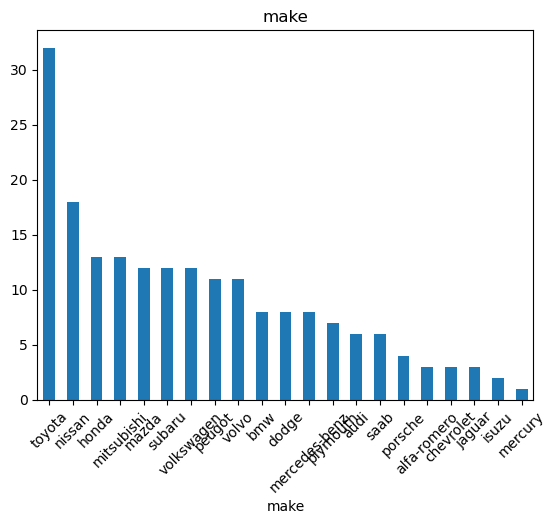

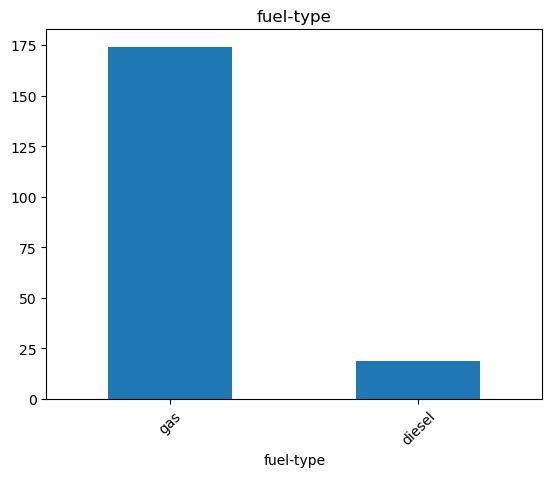

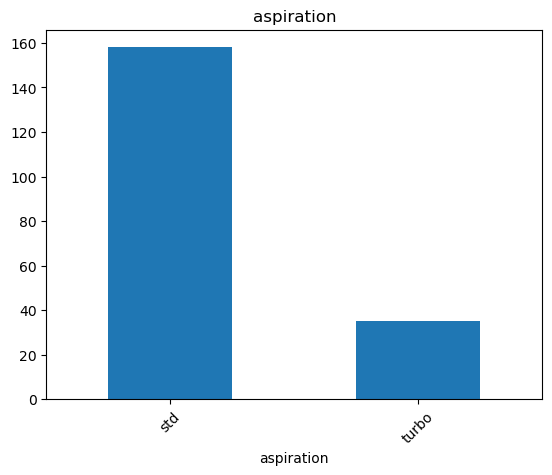

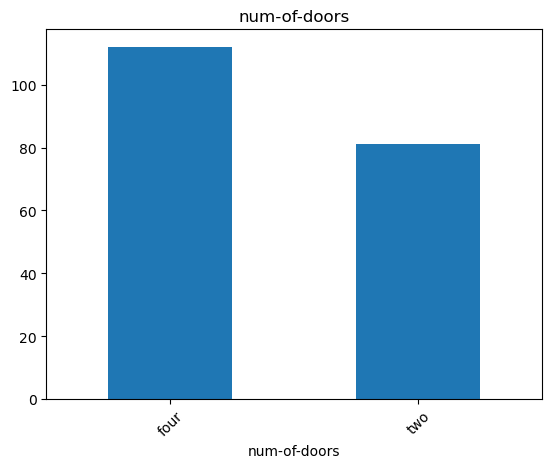

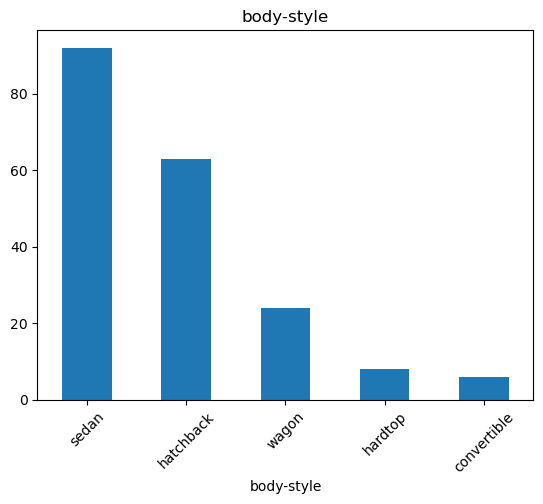

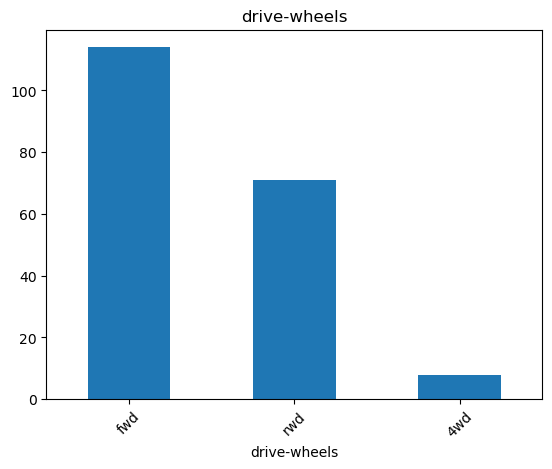

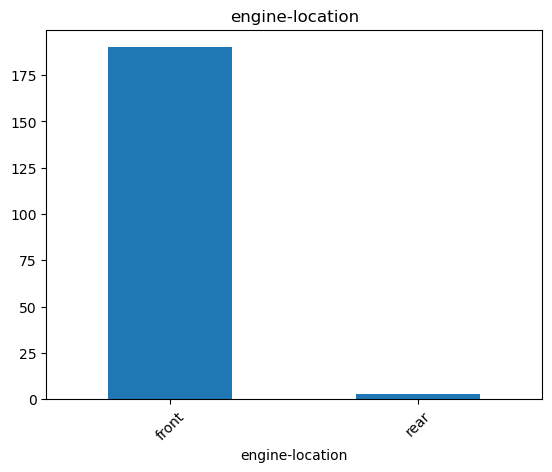

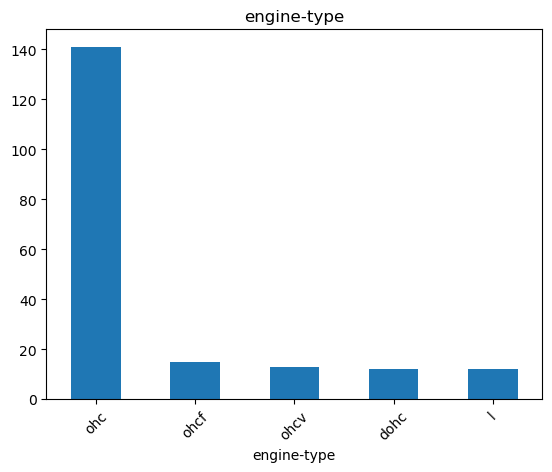

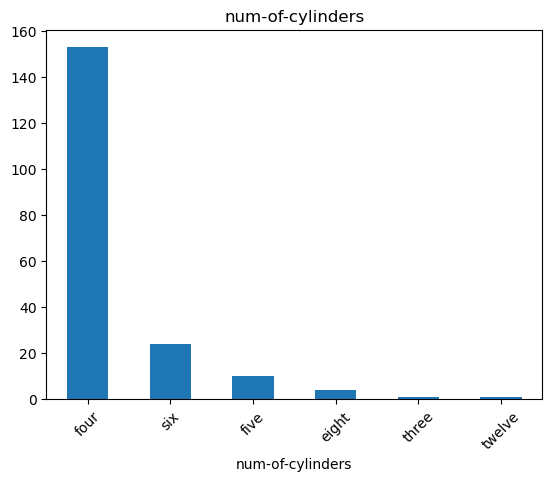

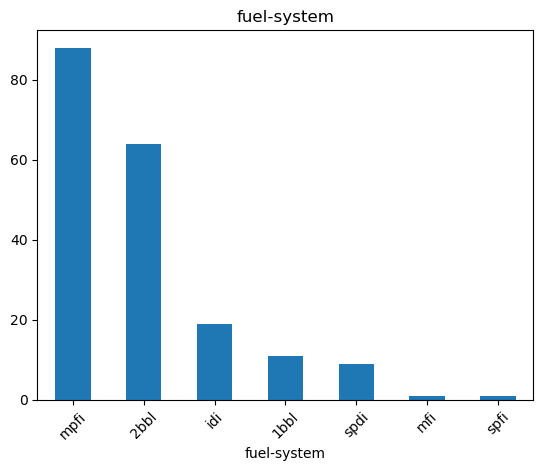

In [103]:
import matplotlib.pyplot as plt
for cols in cols4:
    auto_price[cols].value_counts().plot(
        kind = "bar",
        title = cols,
        rot=45        
    )
    plt.show()

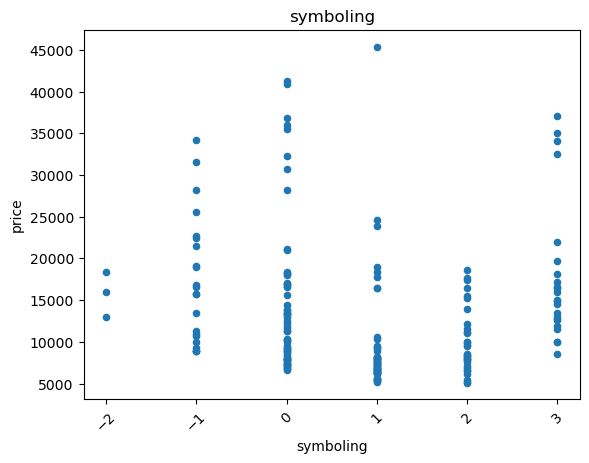

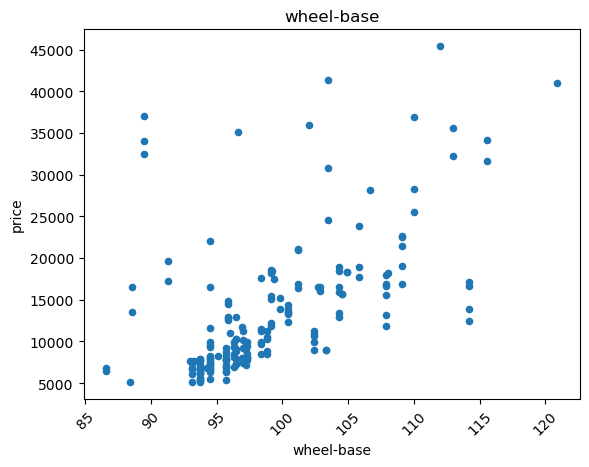

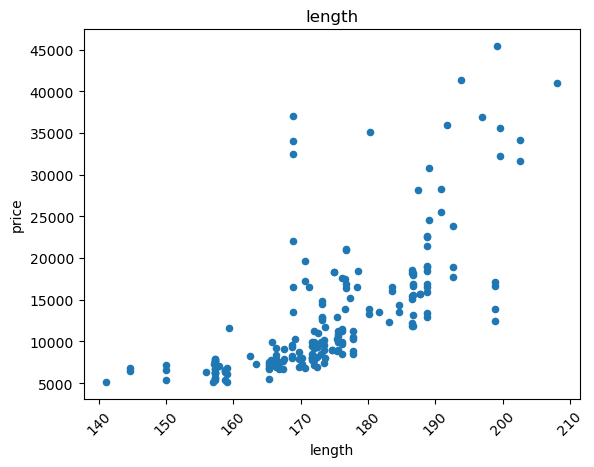

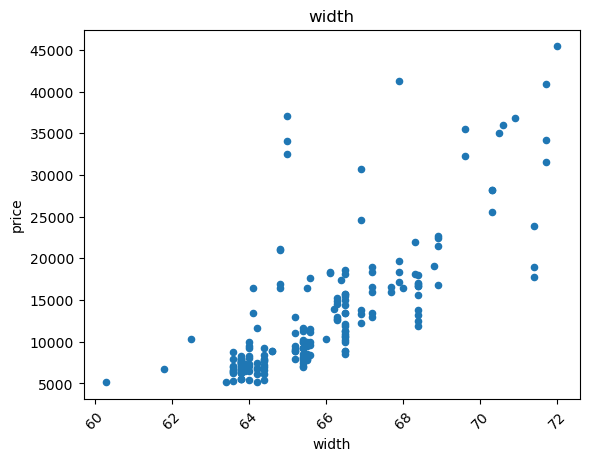

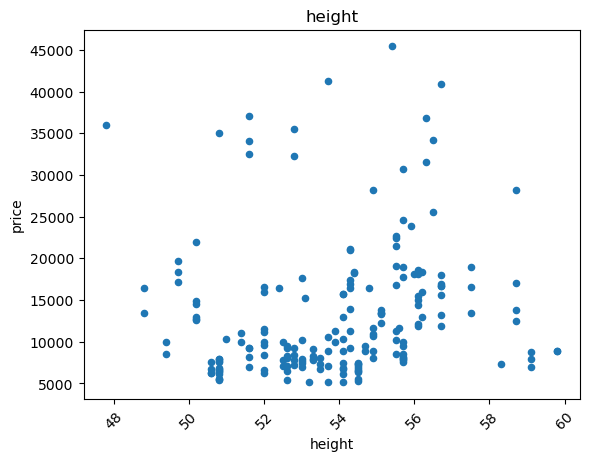

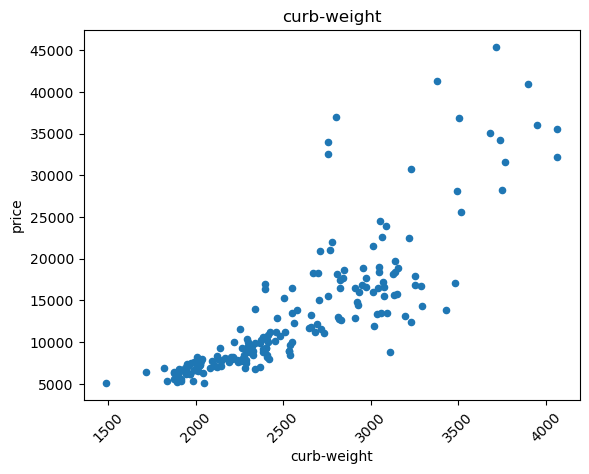

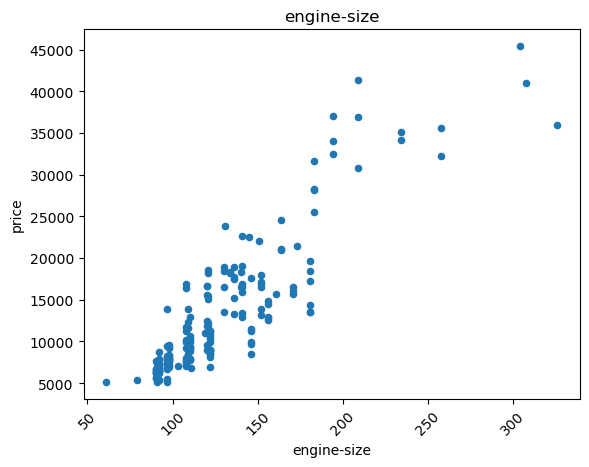

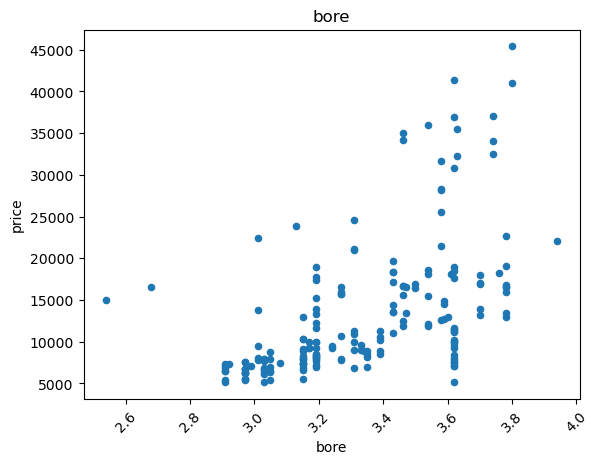

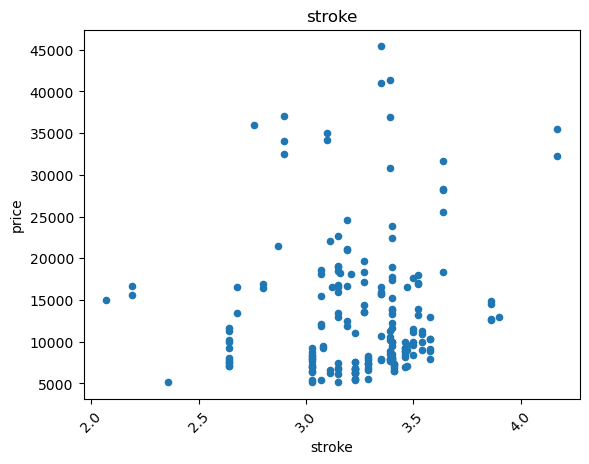

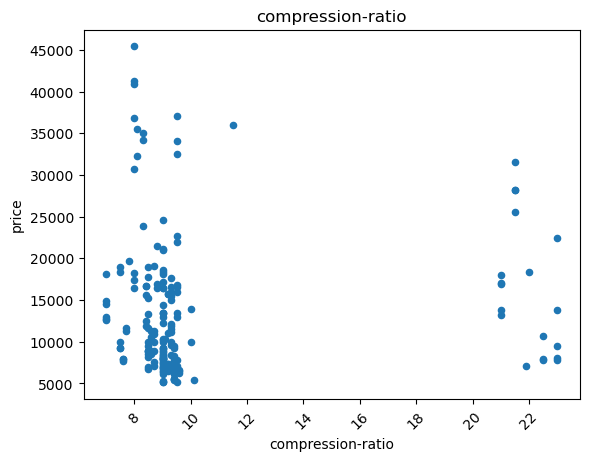

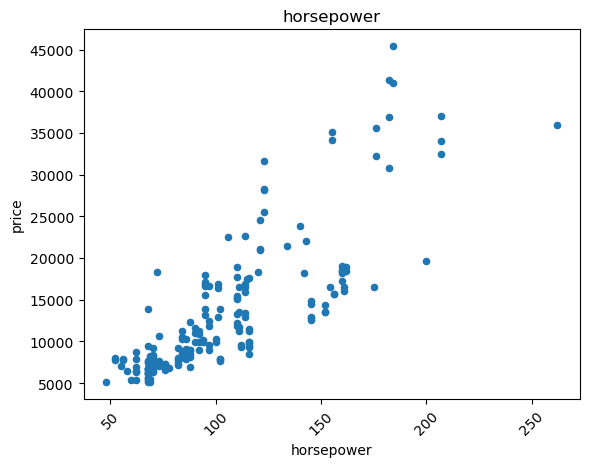

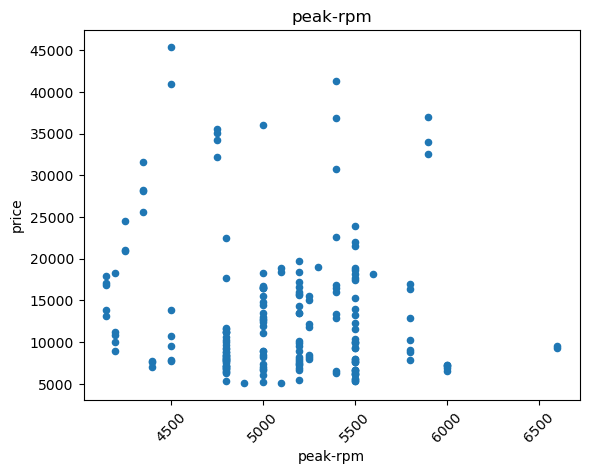

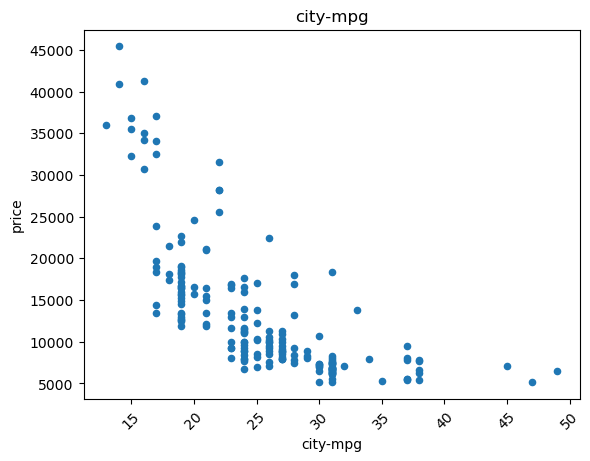

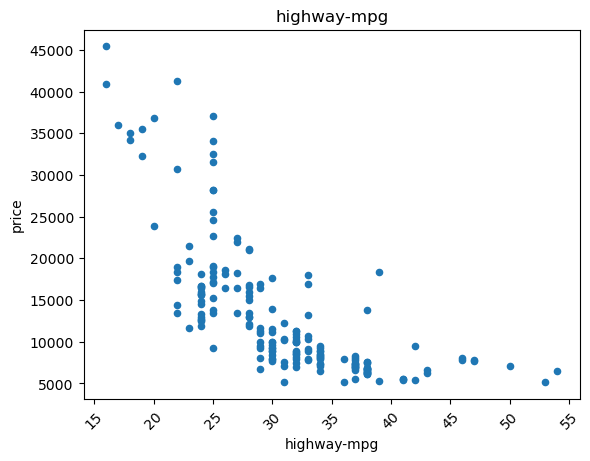

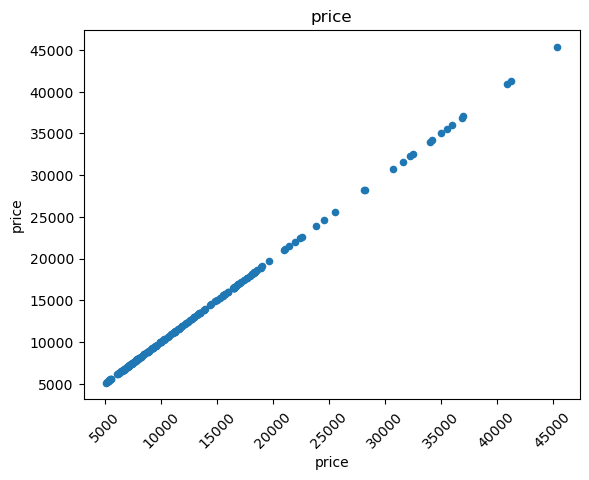

In [104]:
for cols in cols5:
    auto_price.plot(kind="scatter",title=cols,x=cols,y="price",rot=45)
    plt.show()

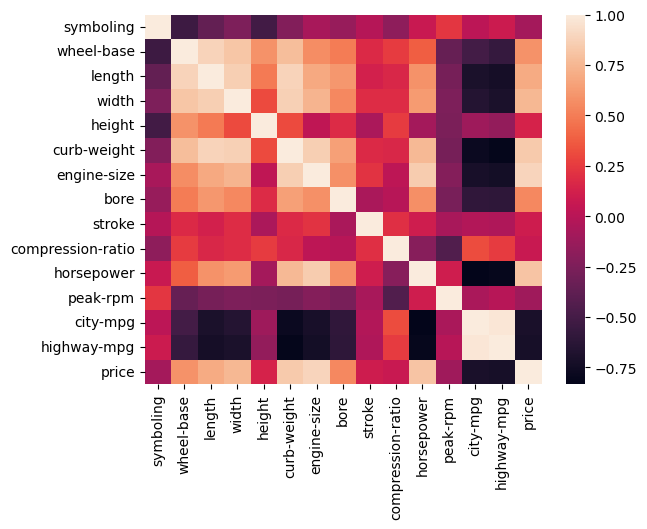

In [105]:
import seaborn as sns
sns.heatmap(auto_price[cols5].corr())
plt.show()

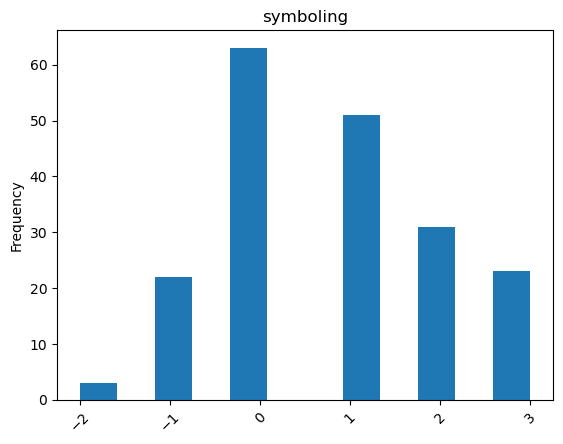

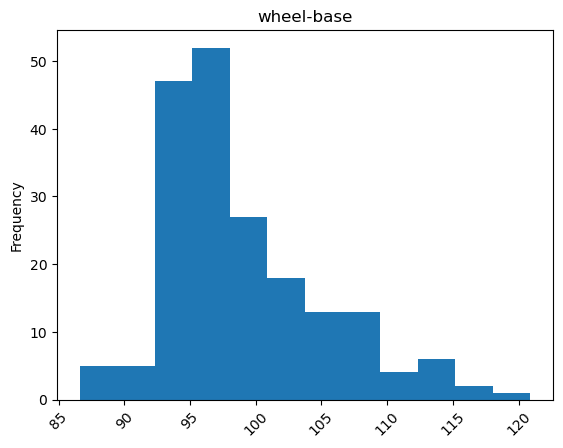

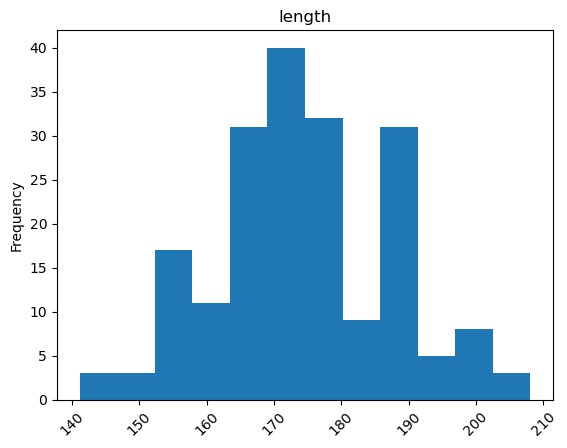

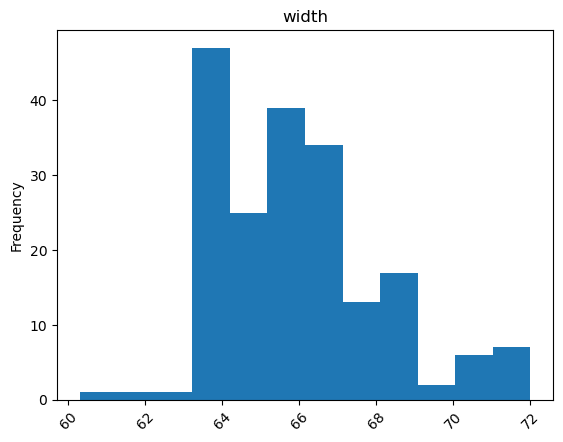

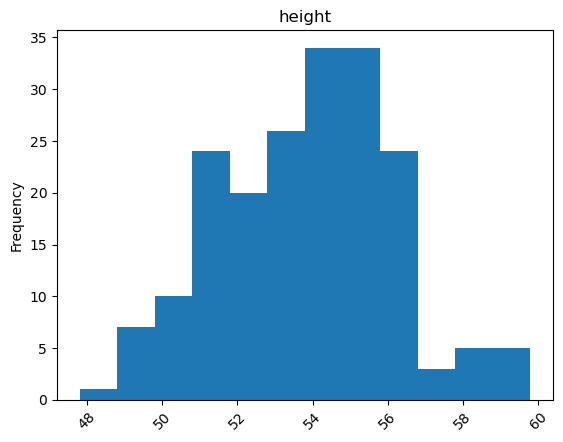

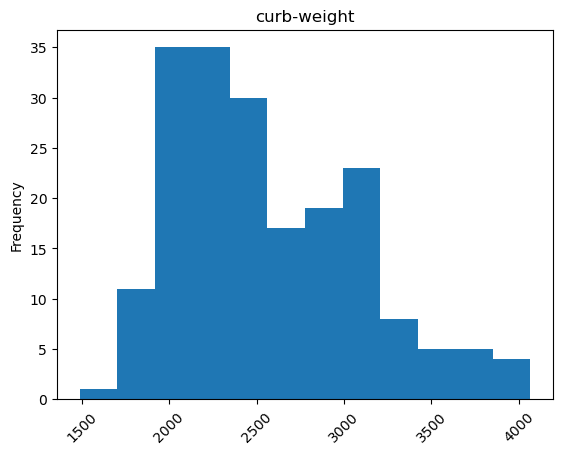

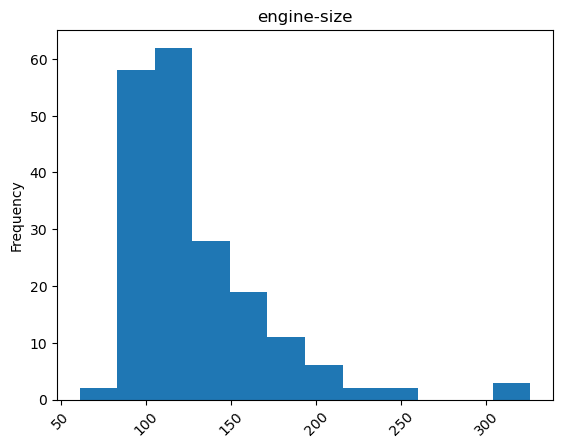

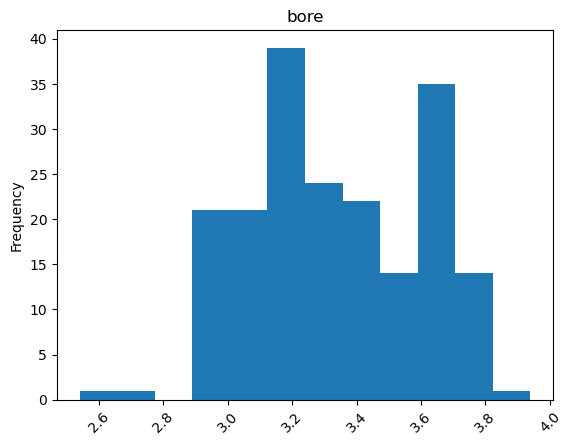

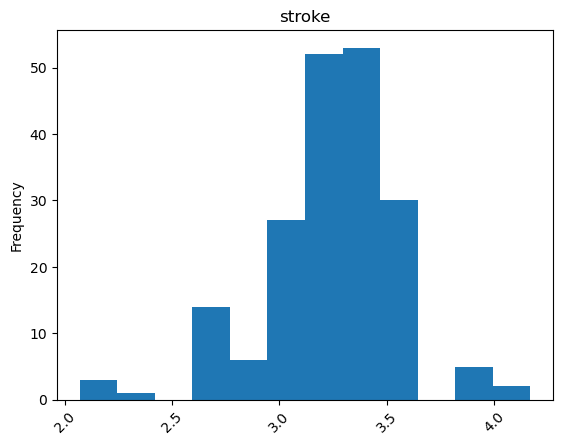

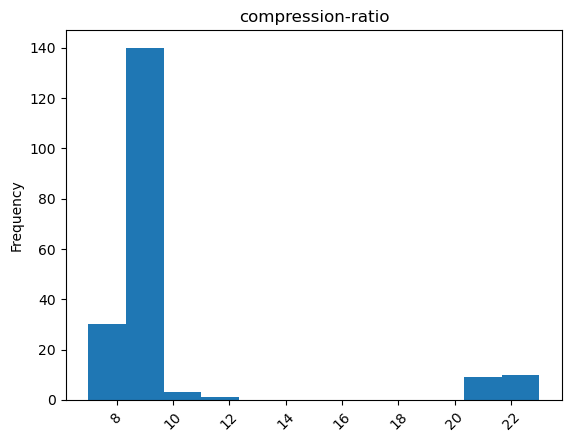

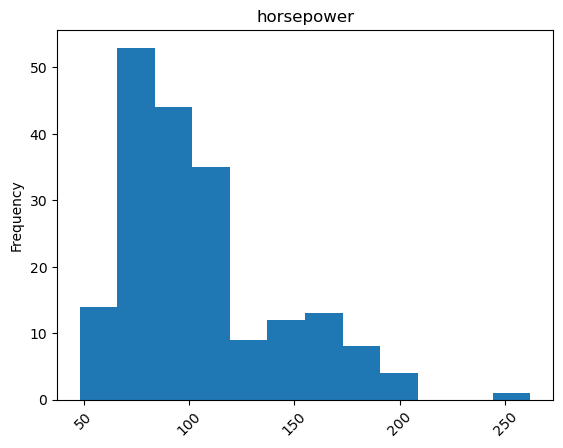

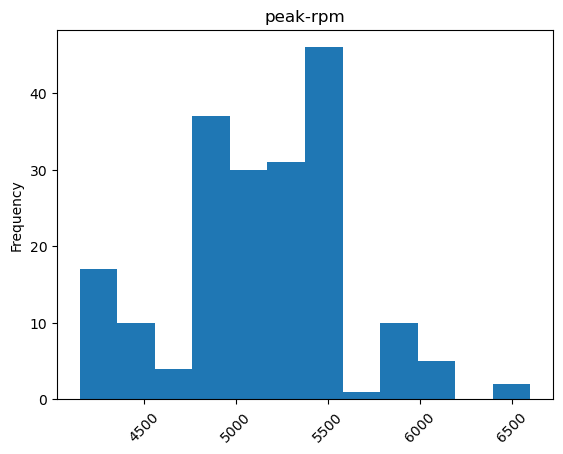

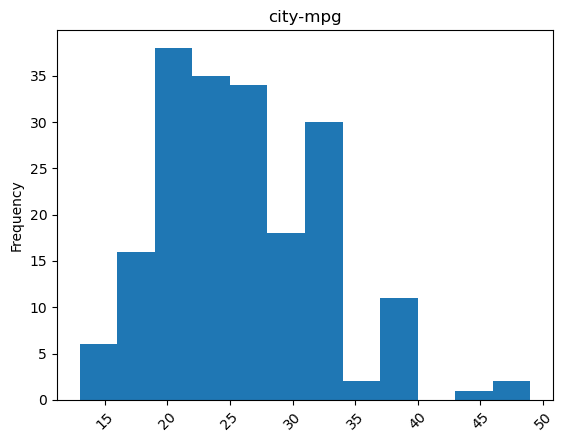

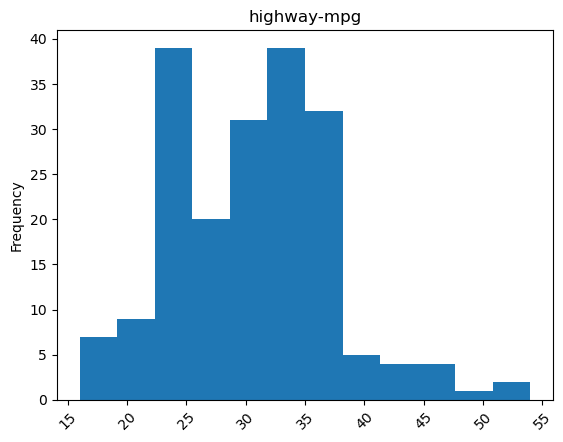

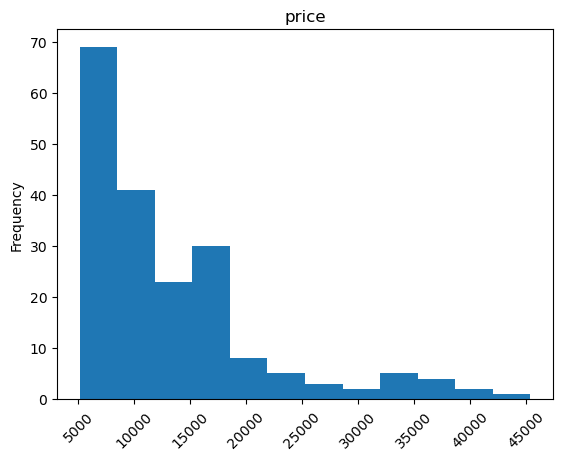

In [107]:
import matplotlib.pyplot as plt
for cols in cols5:
    auto_price[cols].plot(
        kind = "hist",
        bins = 12,
        title = cols,
        rot = 45        
    )
    plt.show()

In [110]:
print('假設跑步為a，跳繩為b')
a_mean=25
b_mean=10
a_std=2.3
b_std=5.9
a_cv = a_std / a_mean
b_cv = b_std / b_mean
print(a_cv)
print(f"{b_cv:.2f}")
#越大表示離散越大

假設跑步為a，跳繩為b
0.092
0.59


In [113]:
import pandas as pd
import numpy as np
fortune = pd.read_csv("fortune1000.csv",index_col="Rank")
fortune.head()
a = fortune["Revenue"]
b = fortune["Employees"]
print(np.corrcoef(a,b))

[[1.         0.72575731]
 [0.72575731 1.        ]]


## 線性迴歸訓練預估

In [114]:
import pandas as pd
tvmarketing = pd.read_csv("tvmarketing.csv")
tvmarketing.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [117]:
#tvmarketing 是否有空值
print(tvmarketing.isnull().any())
#tvmarketing 類型
print(tvmarketing.info())
print(tvmarketing.dtypes)

TV       False
Sales    False
dtype: bool
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None
TV       float64
Sales    float64
dtype: object


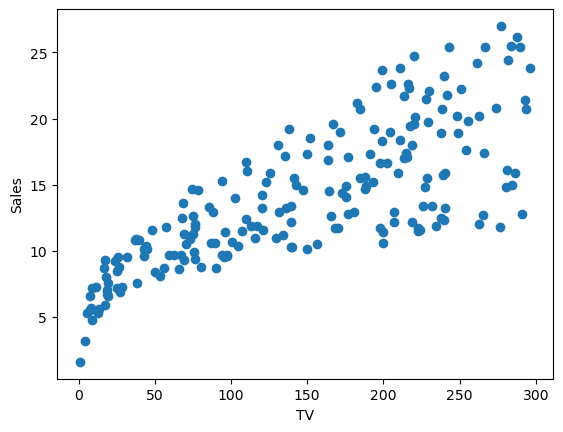

In [118]:
import matplotlib.pyplot as plt
plt.scatter(tvmarketing["TV"],tvmarketing["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

In [128]:
from sklearn.model_selection import train_test_split
X = tvmarketing["TV"]
y = tvmarketing["Sales"]
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.3)#70% 做訓練 30%做測試
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((140,), (60,), (140,), (60,))

In [129]:
import sklearn.linear_model
model = sklearn.linear_model.LinearRegression()

In [130]:
import numpy as np
X_train = np.array(X_train).reshape(-1,1)
print(X_train.shape)
model.fit(X_train,y_train)
print("係數:",model.coef_)
print("截距:",model.intercept_)
#y = ax+b

(140, 1)
係數: [0.04807268]
截距: 7.013800418643147


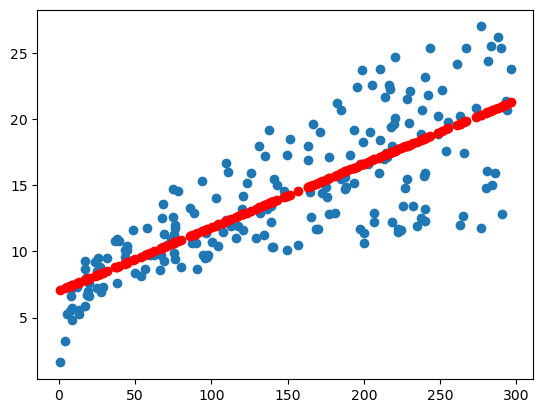

In [132]:
import matplotlib.pyplot as plt
X2 = np.array(X).reshape(1,-1)
y2 = model.coef_ * X2 + model.intercept_
plt.scatter(X2,y)
plt.scatter(X2,y2,c="red")
plt.show()


In [133]:
import numpy as np
array1 = np.eye(4)
print(array1)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [136]:
array2 = np.array([[3,5,6,8],
                   [13,25,46,98],
                   [111,234,556,567]])
print(array2)
print(array2.T)

[[  3   5   6   8]
 [ 13  25  46  98]
 [111 234 556 567]]
[[  3  13 111]
 [  5  25 234]
 [  6  46 556]
 [  8  98 567]]


In [137]:
s = [[1,2],
     [2,1]]
s = np.array(s)
print(s)
print(s.T)

[[1 2]
 [2 1]]
[[1 2]
 [2 1]]


In [139]:
import numpy as np
a1 = np.array([[6,3],
          [8,10]])
a2 = np.array([[2,1],
                [5,-3]])
ans = a1 + a2
ans2 = a1 - a2
print(ans)
print(ans2)

[[ 8  4]
 [13  7]]
[[ 4  2]
 [ 3 13]]


In [141]:
import numpy as np
a = [[15,14,15],
     [12,13,17]]
b = [[10,14],
    [5,18],
    [8,10]]
a = np.array(a)
b = np.array(b)
print(a.shape)
print(b.shape)
print(a@b)

(2, 3)
(3, 2)
[[340 612]
 [321 572]]


In [142]:
import numpy as np
a = np.array([[4,-7],
              [2,-3]])
a_inv = np.linalg.inv(a)
print(a_inv)
print(a@a_inv)


[[-1.5  3.5]
 [-1.   2. ]]
[[1. 0.]
 [0. 1.]]


In [147]:
print('總金額 除以 單價')
print('總金額 乘以 單價的反矩陣')
print('得到反矩陣代表可以被整除')
price1=np.array([[3,3.5],
                 [3.2,3.6]])
total=[[118.4,135.2]]
peicel_inv = np.linalg.inv(price1)
print(peicel_inv)
c = total @ peicel_inv
print(c @ price1)

總金額 除以 單價
總金額 乘以 單價的反矩陣
得到反矩陣代表可以被整除
[[-9.    8.75]
 [ 8.   -7.5 ]]
[[118.4 135.2]]


In [150]:
import numpy as np
B = np.array([[1,2],
              [4,8]])
b_inv = np.linalg.inv(B)


LinAlgError: Singular matrix